<h1><b>SHM Fatigue Damage Model Training</b></h1>

<h4><b>Background Information</b></h4>

The SHM subsystem in NEBULA X Problem Statement 3 asks for the cumulative fatigue damage of a structure to be
estimated from a dynamic-stress recording. Predictions are scored with `max(0, 1 - MAPE)`, where MAPE is the
mean absolute percentage error across the held-out recordings, so a model that is consistently a little off
scores predictably regardless of whether the true damage happens to be small or large. The exploratory analysis
found 64 labelled Train recordings and 16 unlabelled Test recordings, a damage range spanning a factor of 32,
and damage sums under Miner's rule at an S-N exponent near 5 that correlate with damage at a Pearson r of 0.9994
in log-log space.

<h4><b>Objective</b></h4>

This notebook builds damage-regression models from a single calibrated constant upwards and evaluates each one
on the four damage-band folds defined during preprocessing, using the official score. Every model architecture
is tracked as its own MLflow experiment on DagsHub (`shm_baseline`, `shm_power_law`, `shm_elastic_net`,
`shm_gradient_boosting`, `shm_damage_curve`), the architectures are compared, and the selected model is refitted,
registered and used to predict the damage of the Test recordings.

<h4><b>Project Workflow</b></h4>

The notebook sets up the environment and experiment tracking, loads the preprocessed features and rainflow
cycles, defines the performance metric and the shared model utilities, and then builds five architectures of
increasing complexity: a calibrated constant and a fixed Miner's-rule baseline, a power-law regression whose S-N
exponent is tuned by cross-validation and, going further, optimised as a continuous value directly from the raw
cycles, a regularised linear model and a gradient-boosted model on the full feature set, and a nonparametric
damage-rate curve that learns how much each cycle range contributes to damage directly from the rainflow cycles,
without assuming a power law at all. The architectures are then compared, one is selected, refitted and
registered, and the Test predictions are produced.

<h4><b>Dataset Used</b></h4>

The inputs are the outputs of `shm_preprocessing.ipynb` in `data/processed/shm`: the per-recording feature
table, the merged rainflow cycles and the preprocessing manifest. The raw recordings and `Train_Labels.csv` in
`PS3/02_Datasets/SHM` are used only to confirm fingerprints and labels.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Settings</a></li>
      <li><a href="#1-2">1.2 Paths and Configuration</a></li>
      <li><a href="#1-3">1.3 Experiment Tracking</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data and Features</a>
    <ul>
      <li><a href="#2-1">2.1 Preprocessed Tables</a></li>
      <li><a href="#2-2">2.2 Source Check and Data Version</a></li>
      <li><a href="#2-3">2.3 Labels</a></li>
      <li><a href="#2-4">2.4 Feature Table</a></li>
      <li><a href="#2-5">2.5 Test Feature Coverage</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Performance Metric</a>
    <ul>
      <li><a href="#3-1">3.1 MAPE-Derived Score</a></li>
      <li><a href="#3-2">3.2 Held-Out Summary</a></li>
      <li><a href="#3-3">3.3 Evaluation Plots</a></li>
      <li><a href="#3-4">3.4 Recording Evaluations in MLflow</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Model Utilities</a>
    <ul>
      <li><a href="#4-1">4.1 Validation Folds</a></li>
      <li><a href="#4-2">4.2 Model Inputs</a></li>
      <li><a href="#4-3">4.3 Cross-Validation</a></li>
      <li><a href="#4-4">4.4 Experiment Runner</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Baseline</a>
    <ul>
      <li><a href="#5-1">5.1 Optimal Constant</a></li>
      <li><a href="#5-2">5.2 Miner's Rule at a Fixed Exponent</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Power Law With a Tuned Exponent</a>
    <ul>
      <li><a href="#6-1">6.1 Exponent Selected by Cross-Validation</a></li>
      <li><a href="#6-2">6.2 Continuous Exponent From the Cycles</a></li>
      <li><a href="#6-3">6.3 Exponent and Endurance Threshold</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Regularised Linear Model</a>
    <ul>
      <li><a href="#7-1">7.1 Elastic Net Regressor</a></li>
      <li><a href="#7-2">7.2 All Features</a></li>
      <li><a href="#7-3">7.3 Feature-Group Ablations</a></li>
      <li><a href="#7-4">7.4 Coefficients</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Gradient Boosting</a>
    <ul>
      <li><a href="#8-1">8.1 LightGBM Regressor</a></li>
      <li><a href="#8-2">8.2 All Features</a></li>
      <li><a href="#8-3">8.3 Without Damage-Sum Features</a></li>
      <li><a href="#8-4">8.4 MAPE Objective</a></li>
      <li><a href="#8-5">8.5 Feature Importance</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Nonparametric Damage-Rate Curve</a>
    <ul>
      <li><a href="#9-1">9.1 Log-Range Histograms</a></li>
      <li><a href="#9-2">9.2 Monotonic Damage-Rate Ranker</a></li>
      <li><a href="#9-3">9.3 All Recordings</a></li>
      <li><a href="#9-4">9.4 Learned Curve Shape</a></li>
      <li><a href="#9-5">9.5 Knot-Count Sensitivity</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Model Comparison</a>
    <ul>
      <li><a href="#10-1">10.1 Results Across Experiments</a></li>
      <li><a href="#10-2">10.2 Comparison Plot</a></li>
      <li><a href="#10-3">10.3 Model Selection</a></li>
    </ul>
  </li>
  <li><a href="#section-11">Section 11: Final Model</a>
    <ul>
      <li><a href="#11-1">11.1 Refit on All Train Recordings</a></li>
      <li><a href="#11-2">11.2 Model Package</a></li>
      <li><a href="#11-3">11.3 Registration</a></li>
      <li><a href="#11-4">11.4 Submission Format</a></li>
      <li><a href="#11-5">11.5 Package Checks</a></li>
      <li><a href="#11-6">11.6 Test Predictions</a></li>
      <li><a href="#11-7">11.7 Test Predictions by Damage Band</a></li>
    </ul>
  </li>
  <li><a href="#section-12">Section 12: Conclusions</a>
    <ul>
      <li><a href="#12-1">12.1 Results by Architecture</a></li>
      <li><a href="#12-2">12.2 Selected Model and Test Predictions</a></li>
      <li><a href="#12-3">12.3 Limitations</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup</b></h2>
</div>

This section imports the libraries, locates the data, fixes the settings used throughout, and connects MLflow to the project's DagsHub repository.

<blockquote><h3 id="1-1"><b>1-1 Libraries and Settings</b></h3></blockquote>

The notebook uses pandas and NumPy for data handling, SciPy for the exponent search and the damage-rate curve, scikit-learn and LightGBM for the learned models, and MLflow with DagsHub for experiment tracking. A fixed seed makes every result reproducible.

In [1]:
from pathlib import Path
import os
import io
import json
import time
import uuid
import hashlib
import logging
import warnings
import contextlib
import subprocess
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats
import lightgbm as lgb
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
import mlflow
import mlflow.pyfunc
from mlflow import MlflowClient
from mlflow.models import infer_signature
from IPython.display import display

SEED = 2026
COLORS = {'Train': '#16857b', 'candidate': '#2878a5', 'variant': '#9a9a9a', 'accent': '#d95f38'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 170)
for logger_name in ['mlflow', 'alembic']:
    logging.getLogger(logger_name).setLevel(logging.WARNING)  # MLflow resets its level on import, so set it after

<blockquote><h3 id="1-2"><b>1-2 Paths and Configuration</b></h3></blockquote>

The data folders are found from the working directory; `TFD_PS3_DIR` and `TFD_PROCESSED_DIR` override them. Every setting that affects the results is gathered in one configuration, which each MLflow run records.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder from `TFD_PS3_DIR` or the working directory and its parents."""
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


REPO_ROOT = find_repo_root()
SHM_DIR = find_dataset('SHM')
PROCESSED_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'shm'
OUTPUT_DIR = PROCESSED_DIR / 'training'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': SEED,
    'registered_model': 'shm_damage_regressor',
    'dagshub': {'repo_owner': 'kaz-uuu', 'repo_name': 'lta-train-fault-detection'},
    'm_grid': list(range(1, 13)),
    'm_bounds': (1.0, 15.0),
    'threshold_bounds': (0.0, 3.0),
    'alpha_grid': [0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
    'l1_ratio': 0.5,
    'lightgbm': {'n_estimators': 150, 'learning_rate': 0.05, 'num_leaves': 4, 'min_child_samples': 5,
                 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.5, 'reg_lambda': 1.0},
    'curve_knots': 40,
    'curve_lambda_grid': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
    'bootstrap_draws': 10000,
}


def flatten(settings, prefix=''):
    """Nested settings as one mapping with dotted keys."""
    flat = {}
    for key, value in settings.items():
        flat.update(flatten(value, f'{prefix}{key}.') if isinstance(value, dict) else {f'{prefix}{key}': value})
    return flat


display(pd.Series(flatten(CONFIG), name='value').to_frame())

,value
seed,2026
registered_model,shm_damage_regressor
dagshub.repo_owner,kaz-uuu
dagshub.repo_name,lta-train-fault-detection
m_grid,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
m_bounds,"(1.0, 15.0)"
threshold_bounds,"(0.0, 3.0)"
alpha_grid,"[0.003, 0.01, 0.03, 0.1, 0.3, 1.0]"
l1_ratio,0.5
lightgbm.n_estimators,150


<blockquote><h3 id="1-3"><b>1-3 Experiment Tracking</b></h3></blockquote>

MLflow logs to the DagsHub repository `kaz-uuu/lta-train-fault-detection` through `dagshub.init`, using the login stored on this machine by `dagshub login`. Each model architecture gets its own experiment named `shm_<architecture>`, and each evaluated configuration is one run inside it. The runs of one execution share a `notebook_run` tag so that the comparison later reads back exactly this execution. Setting `TFD_MLFLOW=local` logs to a local SQLite store instead, and an explicit `MLFLOW_TRACKING_URI` takes precedence over both.

In [3]:
TRACKING = 'uri' if os.environ.get('MLFLOW_TRACKING_URI') else os.environ.get('TFD_MLFLOW', 'dagshub')
if TRACKING == 'dagshub':
    import dagshub
    dagshub.init(repo_owner=CONFIG['dagshub']['repo_owner'], repo_name=CONFIG['dagshub']['repo_name'], mlflow=True)
elif TRACKING == 'local':
    mlflow.set_tracking_uri(f"sqlite:///{(REPO_ROOT / 'mlflow.db').as_posix()}")
TRACKING_URI = mlflow.get_tracking_uri()
mlflow.set_registry_uri(TRACKING_URI)
client = MlflowClient()
NOTEBOOK_RUN = uuid.uuid4().hex[:8]


def git(*args):
    """Output of a git command run in the repository, or an empty string when git is unavailable."""
    try:
        return subprocess.run(['git', *args], cwd=REPO_ROOT, capture_output=True, text=True, timeout=10).stdout.strip()
    except (OSError, subprocess.SubprocessError):
        return ''


GIT = {'git_commit': git('rev-parse', '--short', 'HEAD') or 'unknown',
       'git_branch': git('rev-parse', '--abbrev-ref', 'HEAD') or 'unknown'}


def experiment_id(name):
    """Id of the MLflow experiment `name`, created on first use."""
    found = client.get_experiment_by_name(name)
    if found is not None:
        return found.experiment_id
    location = (REPO_ROOT / 'mlartifacts').as_uri() if TRACKING_URI.startswith('sqlite') else None
    return client.create_experiment(name, artifact_location=location)


print('Tracking to:', TRACKING_URI if TRACKING != 'local' else 'local SQLite store (mlflow.db)')
print('Runs of this execution are tagged notebook_run =', NOTEBOOK_RUN)

Tracking to: local SQLite store (mlflow.db)
Runs of this execution are tagged notebook_run = 3d7dcd2d


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data and Features</b></h2>
</div>

This section loads the preprocessed tables, confirms they still match the raw recordings, checks the labels, and assembles the feature table. Two findings of the exploratory analysis shape the modelling: the damage sum at S-N exponent 5 already predicts damage almost perfectly in log-log space, so the baseline and the first learned architecture are built directly on it; and the merged rainflow cycles let the training notebook go beyond the preprocessed feature columns, computing a damage sum at any exponent, or a damage-rate curve that assumes no exponent at all, directly from the cycle ranges and counts.

<blockquote><h3 id="2-1"><b>2-1 Preprocessed Tables</b></h3></blockquote>

Three tables from the preprocessing notebook are read: the per-recording audit table, the feature table and the merged rainflow cycles, together with the preprocessing manifest. Only the feature table and the cycles are used as model input; the audit table is read so that any change to it is still caught by the source check below.

In [4]:
files = pd.read_parquet(PROCESSED_DIR / 'shm_files.parquet')
features = pd.read_parquet(PROCESSED_DIR / 'shm_features.parquet').rename(columns={'filename': 'file_id'})
cycles = pd.read_parquet(PROCESSED_DIR / 'shm_cycles.parquet').rename(columns={'filename': 'file_id'})
prep_manifest = json.loads((PROCESSED_DIR / 'manifest.json').read_text())
display(pd.DataFrame({name: {'rows': len(t), 'columns': t.shape[1]} for name, t in
                      {'files': files, 'features': features, 'cycles': cycles}.items()}).T)

,rows,columns
files,80,27
features,80,45
cycles,4613757,4


<blockquote><h3 id="2-2"><b>2-2 Source Check and Data Version</b></h3></blockquote>

The fingerprint of every raw file is recomputed and compared with the preprocessing manifest; a mismatch means the preprocessed tables describe different data and stops the notebook. A short data version, derived from the fingerprints of the preprocessed tables, is attached to every MLflow run.

In [5]:
def sha256_file(path):
    """SHA-256 of a file's bytes."""
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


raw_paths = {p.name: p for split in ['Train', 'Test'] for p in (SHM_DIR / split).glob('*.csv')}
raw_paths['Train_Labels.csv'] = SHM_DIR / 'Train_Labels.csv'
mismatched = [name for name, digest in prep_manifest['sources'].items() if sha256_file(raw_paths[name]) != digest]
assert not mismatched, f'Recordings changed since preprocessing: {mismatched}; rerun shm_preprocessing.ipynb.'
TABLES = ['shm_files.parquet', 'shm_features.parquet', 'shm_cycles.parquet']
DATA_VERSION = 'shm-' + hashlib.sha256(''.join(sha256_file(PROCESSED_DIR / t) for t in TABLES).encode()).hexdigest()[:8]
print(f'All {len(prep_manifest["sources"])} raw files match the preprocessing fingerprints; data version {DATA_VERSION}.')

All 81 raw files match the preprocessing fingerprints; data version shm-37976b73.


<blockquote><h3 id="2-3"><b>2-3 Labels</b></h3></blockquote>

The damage of each Train recording is taken from the feature table and checked against `Train_Labels.csv`.

In [6]:
raw_labels = pd.read_csv(SHM_DIR / 'Train_Labels.csv').set_index('filename')['damage']
train_damage = features.set_index('file_id').loc[features['dataset'].eq('Train').to_numpy(), 'damage']
assert np.allclose(raw_labels.reindex(train_damage.index), train_damage)
print(f'Labels reproduce Train_Labels.csv for all {len(train_damage)} Train recordings.')

Labels reproduce Train_Labels.csv for all 64 Train recordings.


<blockquote><h3 id="2-4"><b>2-4 Feature Table</b></h3></blockquote>

The 39 features of preprocessing fall into four groups: 9 signal statistics, 6 range-distribution features, and 12 damage sums with their 12 equivalent ranges at S-N exponents 1 to 12. All features enter the learned models, together with `file_id`, the damage target, its base-10 logarithm, the damage band and the fold that preprocessing already assigned.

In [7]:
GROUPS = prep_manifest['feature_groups']
FEATURES = [f for columns in GROUPS.values() for f in columns]
FEATURE_TABLE = features.astype({'file_id': str, 'dataset': str})
FEATURE_TABLE[FEATURES] = FEATURE_TABLE[FEATURES].astype(float)
assert len(FEATURES) == 39 and FEATURE_TABLE['file_id'].is_unique and len(FEATURE_TABLE) == len(files)
display(pd.DataFrame({group: {'features': len(columns), 'missing values': int(FEATURE_TABLE[columns].isna().sum().sum())}
                      for group, columns in GROUPS.items()}).T)

,features,missing values
signal,9,0
range distribution,6,0
damage sum,12,0
equivalent range,12,0


<blockquote><h3 id="2-5"><b>2-5 Test Feature Coverage</b></h3></blockquote>

The Test recordings should sit inside the range seen in Train. For every feature, the table counts Test recordings outside the Train range, summarised by feature group; extrapolating a damage sum beyond the Train range is where a power-law model is least trustworthy.

In [8]:
is_test = FEATURE_TABLE['dataset'].eq('Test')


def outside_count(values):
    """Test recordings whose value lies outside the Train range of the same column."""
    low, high = values[~is_test].min(), values[~is_test].max()
    return int(((values[is_test] < low) | (values[is_test] > high)).sum())


outside = pd.Series({f: outside_count(FEATURE_TABLE[f]) for f in FEATURES})
display(pd.DataFrame({group: {'features': len(columns), 'features with an out-of-range Test recording': int((outside[columns] > 0).sum())}
                      for group, columns in GROUPS.items()}).T)
display(outside[outside > 0].sort_values(ascending=False).rename('Test recordings outside Train range').to_frame())

,features,features with an out-of-range Test recording
signal,9,6
range distribution,6,2
damage sum,12,0
equivalent range,12,0


,Test recordings outside Train range
half_cycles,2
mean,1
peak_to_peak,1
skewness,1
kurtosis,1
turning_point_rate,1
spectral_centroid,1
cycle_count,1


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Performance Metric</b></h2>
</div>

This section defines the official score, a summary of a held-out evaluation with its uncertainty, the evaluation plots, and the function that records an evaluation in MLflow.

<blockquote><h3 id="3-1"><b>3-1 MAPE-Derived Score</b></h3></blockquote>

The official score is `max(0, 1 - MAPE)`, where MAPE is the mean of `|true - predicted| / |true|` over the held-out recordings; a model floors at 0 once its average error reaches 100%. The implementation is checked against the worked example in the SHM info kit, against the constant guess that also appears there, and on a perfect prediction.

In [9]:
def mape_score(y_true, y_pred):
    """Official SHM score: max(0, 1 - MAPE), MAPE = mean(|true - pred| / |true|)."""
    ape = np.abs(y_true - y_pred) / np.abs(y_true)
    mape = float(np.mean(ape))
    return mape, max(0.0, 1.0 - mape)


checks = {
    'perfect predictions score 1': mape_score(np.array([0.2, 0.6]), np.array([0.2, 0.6]))[1] == 1.0,
    'worked example scores 0.850': np.isclose(
        mape_score(np.array([0.10, 0.30, 0.50, 0.70, 0.90]), np.array([0.15, 0.28, 0.55, 0.68, 0.85]))[1], 0.850, atol=1e-3),
    'constant 0.5 guess floors at 0': mape_score(np.array([0.10, 0.30, 0.50, 0.70, 0.90]), np.full(5, 0.5))[1] == 0.0,
}
assert all(checks.values())
display(pd.Series(checks, name='passed').to_frame())

,passed
perfect predictions score 1,True
worked example scores 0.850,True
constant 0.5 guess floors at 0,True


<blockquote><h3 id="3-2"><b>3-2 Held-Out Summary</b></h3></blockquote>

With 64 recordings in 4 damage-band folds, the headline number needs its uncertainty next to it. The summary reports the pooled score over all out-of-fold predictions, as the Test set will be scored, a bootstrap interval that resamples recordings within each damage band, the mean and spread of the score over the four folds, and the Spearman correlation between true and predicted damage as a scale-free sanity check.

In [10]:
def weighted_median(values, weights):
    """Value minimising the weighted absolute deviation sum(weight * |value - c|)."""
    order = np.argsort(values)
    v, w = values[order], weights[order]
    cdf = np.cumsum(w) / w.sum()
    return float(v[np.searchsorted(cdf, 0.5)])


def bootstrap_interval(ape, damage_band, draws, seed):
    """95% percentile interval of the pooled score when recordings are resampled within each damage band."""
    rng = np.random.default_rng(seed)
    idx_by_band = [np.flatnonzero(damage_band == b) for b in sorted(np.unique(damage_band))]
    samples = np.concatenate([rng.choice(idx, size=(draws, len(idx))) for idx in idx_by_band], axis=1)
    scores = np.maximum(0.0, 1.0 - ape[samples].mean(axis=1))
    return np.percentile(scores, [2.5, 97.5])


def summarise(predictions):
    """Headline numbers of one evaluation from its pooled out-of-fold predictions."""
    y, p = predictions['damage'].to_numpy(), predictions['prediction'].to_numpy()
    ape = np.abs(y - p) / np.abs(y)
    mape, score = mape_score(y, p)
    low, high = bootstrap_interval(ape, predictions['damage_band'].to_numpy(), CONFIG['bootstrap_draws'], SEED)
    by_fold = predictions.groupby('fold').apply(lambda g: mape_score(g['damage'].to_numpy(), g['prediction'].to_numpy())[1],
                                                include_groups=False)
    return {'score': score, 'mape': mape, 'score_ci_low': float(low), 'score_ci_high': float(high),
            'score_fold_mean': float(by_fold.mean()), 'score_fold_std': float(by_fold.std(ddof=1)),
            'spearman': float(stats.spearmanr(y, p).statistic), 'n_recordings': len(y), 'n_folds': int(by_fold.size)}


CONSTANT_SCORE = mape_score(FEATURE_TABLE.loc[~is_test, 'damage'].to_numpy(),
                            np.full((~is_test).sum(), weighted_median(FEATURE_TABLE.loc[~is_test, 'damage'].to_numpy(),
                                                                      1 / FEATURE_TABLE.loc[~is_test, 'damage'].to_numpy())))[1]
print(f'Score of the best constant prediction on all Train recordings: {CONSTANT_SCORE:.4f}')

Score of the best constant prediction on all Train recordings: 0.4402


<blockquote><h3 id="3-3"><b>3-3 Evaluation Plots</b></h3></blockquote>

Two plots recur throughout: predicted against true damage on a log-log scale, which shows where a model goes wrong and by how much, and the percentage error against true damage, which shows whether that error is concentrated at the low or high end of the damage range; and a bar chart of pooled score with intervals, which compares models against the best constant prediction.

In [11]:
def prediction_figure(predictions, title):
    """Predicted against true damage (log-log) and percentage error against true damage."""
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.4))
    y, p = predictions['damage'].to_numpy(), predictions['prediction'].to_numpy()
    lims = (min(y.min(), p[p > 0].min() if (p > 0).any() else y.min()) * 0.8, max(y.max(), p.max()) * 1.25)
    axes[0].plot(lims, lims, color='grey', linewidth=1, linestyle='--')
    axes[0].scatter(y, np.clip(p, lims[0], None), s=18, alpha=0.75, color=COLORS['Train'])
    axes[0].set(xscale='log', yscale='log', xlim=lims, ylim=lims, xlabel='True damage', ylabel='Predicted damage')
    axes[1].axhline(0, color='grey', linewidth=1)
    axes[1].scatter(y, 100 * (p - y) / y, s=18, alpha=0.75, color=COLORS['Train'])
    axes[1].set(xscale='log', xlabel='True damage', ylabel='Percentage error')
    fig.suptitle(title, fontsize=9)
    return fig


def comparison_figure(table):
    """Pooled score per run with bootstrap intervals; candidates coloured, variants grey."""
    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = np.arange(len(table))
    ax.bar(x, table['score'], color=[COLORS['candidate'] if r == 'candidate' else COLORS['variant'] for r in table['role']])
    ax.errorbar(x, table['score'], yerr=[table['score'] - table['CI low'], table['CI high'] - table['score']],
                fmt='none', ecolor='black', capsize=3, linewidth=1)
    ax.axhline(CONSTANT_SCORE, color='black', linestyle='--', linewidth=1, label=f'best constant prediction ({CONSTANT_SCORE:.3f})')
    ax.set(xticks=x, ylim=(0, 1.05), ylabel='Pooled out-of-fold score')
    ax.set_xticklabels(table.index, rotation=30, ha='right', fontsize=8)
    ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), frameon=False)
    return fig

<blockquote><h3 id="3-4"><b>3-4 Recording Evaluations in MLflow</b></h3></blockquote>

Each evaluated configuration becomes one run in the experiment of its architecture. The run records the configuration as parameters, the headline numbers and the score of every fold as metrics, the per-fold table, the out-of-fold predictions, any model-specific tables and the prediction figure, together with tags for the code version, data version, split and role. The role is `candidate` for configurations that compete for selection and `variant` for diagnostic runs.

In [12]:
def log_evaluation(experiment, run_name, result, params, role, tables=None):
    """Record one evaluated configuration as a run of `experiment` and return the run id."""
    tags = {'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'split': result['split'], 'role': role}
    with mlflow.start_run(experiment_id=experiment_id(experiment), run_name=run_name, tags=tags) as run:
        mlflow.log_params({**params, 'seed': SEED})
        mlflow.log_metrics({**result['summary'], 'fit_time_s': result['fit_time_s'],
                            **{f'score_fold_{fold}': v for fold, v in result['per_fold'].items()}})
        mlflow.log_text(pd.Series(result['per_fold']).rename('score').rename_axis('fold').reset_index().to_csv(index=False),
                        'per_fold.csv')
        mlflow.log_text(result['predictions'].to_csv(index=False), 'predictions.csv')
        for name, table in (tables or {}).items():
            mlflow.log_text(table.to_csv(), f'{name}.csv')
        fig = prediction_figure(result['predictions'], f'{experiment} / {run_name}')
        mlflow.log_figure(fig, 'predictions.png')
        plt.close(fig)
    return run.info.run_id

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Model Utilities</b></h2>
</div>

This section holds the pieces every model shares: the validation folds, the model inputs, a cross-validation function that works for any model, and a runner that evaluates a configuration and records it.

<blockquote><h3 id="4-1"><b>4-1 Validation Folds</b></h3></blockquote>

The four folds come from the preprocessing notebook: the Train recordings were split into damage quartile bands and dealt to four folds so that each one covers the full damage range. A model that tunes a setting does so inside the training folds only, leaving out each training fold in turn and keeping the setting with the best mean score.

In [13]:
TRAIN = FEATURE_TABLE[FEATURE_TABLE['dataset'].eq('Train')].copy()
TRAIN['fold'] = TRAIN['fold'].astype(int)
TRAIN['damage_band'] = TRAIN['damage_band'].astype(int)
FOLD_IDS = sorted(TRAIN['fold'].unique())
fold_table = pd.crosstab(TRAIN['fold'], TRAIN['damage_band'])
assert fold_table.to_numpy().min() > 0, 'every fold needs every damage band'
assert FEATURE_TABLE.loc[FEATURE_TABLE['dataset'].eq('Test'), 'fold'].isna().all()


def inner_folds(frame):
    """Leave-one-fold-out splits over the folds already present in `frame`."""
    for fold in sorted(frame['fold'].unique()):
        yield frame[frame['fold'].ne(fold)], frame[frame['fold'].eq(fold)]


display(fold_table.assign(recordings=fold_table.sum(axis=1)))
display(TRAIN.groupby('fold')['damage'].agg(['size', 'min', 'median', 'max']).round(4))

damage_band,0,1,2,3,recordings
fold,,,,,
0,4,4,4,4,16
1,4,4,4,4,16
2,4,4,4,4,16
3,4,4,4,4,16


,size,min,median,max
fold,,,,
0,16,0.0286,0.0960,0.8326
1,16,0.0287,0.0982,0.8947
2,16,0.0340,0.0989,0.7165
3,16,0.0286,0.0944,0.9283


<blockquote><h3 id="4-2"><b>4-2 Model Inputs</b></h3></blockquote>

The feature models read rows of the feature table, and the two architectures that work from the raw signal (the continuous power law of Section 6 and the damage-rate curve of Section 9) read the merged rainflow cycles instead; each model states which it needs through `input_level`. The feature models share a small base class that returns one prediction per recording.

In [14]:
def frame_for(level, file_ids):
    """Model input for the given recordings: rows of the feature table, or their rainflow cycles."""
    if level == 'features':
        return FEATURE_TABLE.set_index('file_id').loc[list(file_ids)].reset_index()
    return cycles[cycles['file_id'].isin(list(file_ids))]


class FeatureModel:
    """Base for models that predict damage from one row of recording features."""

    input_level = 'features'
    row_key = ['file_id']

    @property
    def input_columns(self):
        return ['file_id'] + self.features

    def predict_table(self, table):
        return self.predict(table)

    @staticmethod
    def output(frame, prediction):
        return pd.DataFrame({'file_id': frame['file_id'].to_numpy(), 'prediction': np.asarray(prediction, dtype=float)})

<blockquote><h3 id="4-3"><b>4-3 Cross-Validation</b></h3></blockquote>

The cross-validation function takes any model constructor. For each fold it builds a fresh model, fits it on the other three folds, and predicts the held-out recordings; the pooled predictions are then summarised.

In [15]:
def evaluate(make_model):
    """Fit a fresh model per fold on the other folds and predict the held-out recordings."""
    parts, models = [], {}
    start = time.perf_counter()
    for fold in FOLD_IDS:
        model = make_model()
        model.fit(frame_for(model.input_level, TRAIN.loc[TRAIN['fold'].ne(fold), 'file_id']))
        predicted = model.predict(frame_for(model.input_level, TRAIN.loc[TRAIN['fold'].eq(fold), 'file_id']))
        parts.append(predicted.merge(TRAIN[['file_id', 'damage', 'damage_band']], on='file_id').assign(fold=fold))
        models[fold] = model
    predictions = pd.concat(parts, ignore_index=True)
    per_fold = predictions.groupby('fold').apply(lambda g: mape_score(g['damage'].to_numpy(), g['prediction'].to_numpy())[1],
                                                 include_groups=False)
    return {'split': 'damage-band-stratified-4-fold', 'predictions': predictions, 'per_fold': per_fold.to_dict(),
            'models': models, 'summary': summarise(predictions), 'fit_time_s': time.perf_counter() - start}

<blockquote><h3 id="4-4"><b>4-4 Experiment Runner</b></h3></blockquote>

The runner joins evaluation and recording: it evaluates a configuration, logs it as a run named `run_name` in the experiment `shm_<architecture>`, and keeps the result for the comparison. Two helpers present results: one shows the per-fold scores with the headline numbers and the prediction figure, and one lines up several runs.

In [16]:
RESULTS = {}


def run_experiment(architecture, run_name, make_model, params, role='candidate', tables=None):
    """Evaluate one configuration, record it in MLflow, and keep the result."""
    result = evaluate(make_model)
    run_id = log_evaluation(f'shm_{architecture}', run_name, result, params, role, tables(result) if tables else None)
    RESULTS[(architecture, run_name)] = {**result, 'run_id': run_id, 'role': role, 'make_model': make_model, 'params': params}
    return RESULTS[(architecture, run_name)]


def show(result, figure=True):
    """Per-fold scores, the headline numbers and, optionally, the prediction figure."""
    display(pd.Series(result['per_fold'], name='score').rename_axis('fold').to_frame().T)
    s = result['summary']
    print(f"score {s['score']:.4f} (95% interval {s['score_ci_low']:.4f} to {s['score_ci_high']:.4f}) | "
          f"fold mean {s['score_fold_mean']:.4f} (sd {s['score_fold_std']:.4f}) | Spearman {s['spearman']:.4f} | "
          f"MAPE {s['mape']:.4f} | best constant {CONSTANT_SCORE:.4f}")
    if figure:
        prediction_figure(result['predictions'], 'Pooled out-of-fold predictions')
        plt.show()


def score_table(keys):
    """Pooled score and MAPE for several runs."""
    return pd.DataFrame({f'{arch} / {name}': {'score': RESULTS[(arch, name)]['summary']['score'],
                                              'MAPE': RESULTS[(arch, name)]['summary']['mape']}
                         for arch, name in keys}).T

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Baseline</b></h2>
</div>

Unlike a ranking or classification task, an absolute damage prediction needs at least a scale, so neither baseline is entirely unfitted. The first learns nothing about the recordings at all, only the single constant that the metric itself prefers; the second is Miner's rule at the exponent the exploratory analysis found, with only its two log-log parameters fitted. Every later model has to beat them to be worth its extra complexity. Both are recorded in the experiment `shm_baseline`.

<blockquote><h3 id="5-1"><b>5-1 Optimal Constant</b></h3></blockquote>

MAPE is minimised, over a set of training recordings, by the value that minimises the weighted absolute deviation `sum(|damage - c| / damage)`: the weighted median of the training damages with weights `1 / damage`. This is the SHM equivalent of always predicting the majority class.

fold,0,1,2,3
score,0.441258,0.400594,0.443361,0.462802


score 0.4370 (95% interval 0.4082 to 0.4653) | fold mean 0.4370 (sd 0.0261) | Spearman 0.0169 | MAPE 0.5630 | best constant 0.4402


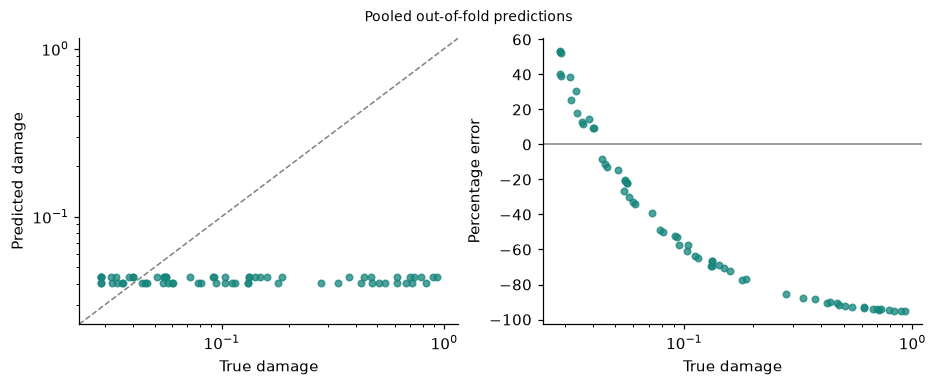

In [17]:
class ConstantDamage(FeatureModel):
    """Predicts the training constant that minimises MAPE for every recording."""

    def __init__(self):
        self.features = []

    def fit(self, frame):
        self.constant_ = weighted_median(frame['damage'].to_numpy(), 1 / frame['damage'].to_numpy())
        return self

    def predict(self, frame):
        return self.output(frame, np.full(len(frame), self.constant_))


result = run_experiment('baseline', 'optimal_constant', ConstantDamage, params={'model': 'optimal_constant'})
show(result)

<blockquote><h3 id="5-2"><b>5-2 Miner's Rule at a Fixed Exponent</b></h3></blockquote>

Under Miner's rule, damage is proportional to the sum of `count * range^m` over the rainflow cycles, so log damage is a straight line in the log of that sum. The rule fits only the slope and intercept of that line by ordinary least squares, at the exponent `m = 5` that the exploratory analysis found to have a log-log Pearson correlation of 0.9994; nothing about which exponent to use is learned here.

fold,0,1,2,3
score,0.979347,0.971194,0.968767,0.968803


score 0.9720 (95% interval 0.9653 to 0.9782) | fold mean 0.9720 (sd 0.0050) | Spearman 0.9977 | MAPE 0.0280 | best constant 0.4402


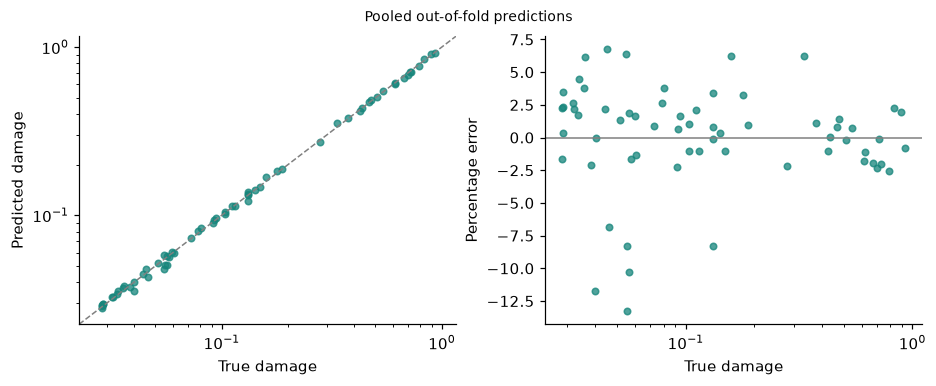

,score,MAPE
baseline / optimal_constant,0.437,0.563
baseline / miners_rule_m5,0.972,0.028


In [18]:
class FixedPowerLaw(FeatureModel):
    """Miner's rule at a fixed S-N exponent: OLS intercept and slope of log damage on one damage-sum feature."""

    def __init__(self, m):
        self.m = m
        self.features = [f'log10_dsum_m{m}']

    def fit(self, frame):
        self.slope_, self.intercept_, *_ = stats.linregress(frame[self.features[0]], frame['log10_damage'])
        return self

    def predict(self, frame):
        return self.output(frame, 10 ** (self.slope_ * frame[self.features[0]].to_numpy() + self.intercept_))


result = run_experiment('baseline', 'miners_rule_m5', lambda: FixedPowerLaw(5), params={'model': 'fixed_power_law', 'm': 5})
show(result)
display(score_table([('baseline', 'optimal_constant'), ('baseline', 'miners_rule_m5')]).round(4))

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Power Law With a Tuned Exponent</b></h2>
</div>

The baseline exponent came from a descriptive correlation on all Train recordings; this architecture instead lets the exponent be chosen by the same held-out validation used to judge every other model, first from the preprocessed grid of integer exponents and then, going beyond what preprocessing computed, as a continuous value optimised directly from the rainflow cycles, with an optional endurance threshold below which small cycles are dropped entirely. Its runs are recorded in the experiment `shm_power_law`.

<blockquote><h3 id="6-1"><b>6-1 Exponent Selected by Cross-Validation</b></h3></blockquote>

For each outer fold, every integer exponent from 1 to 12 is scored by an inner leave-one-fold-out loop on the training folds, and the exponent with the best mean inner score is refitted on all of them; ties go to the smallest exponent.

fold,0,1,2,3
score,0.979347,0.971194,0.968767,0.968803


score 0.9720 (95% interval 0.9653 to 0.9782) | fold mean 0.9720 (sd 0.0050) | Spearman 0.9977 | MAPE 0.0280 | best constant 0.4402


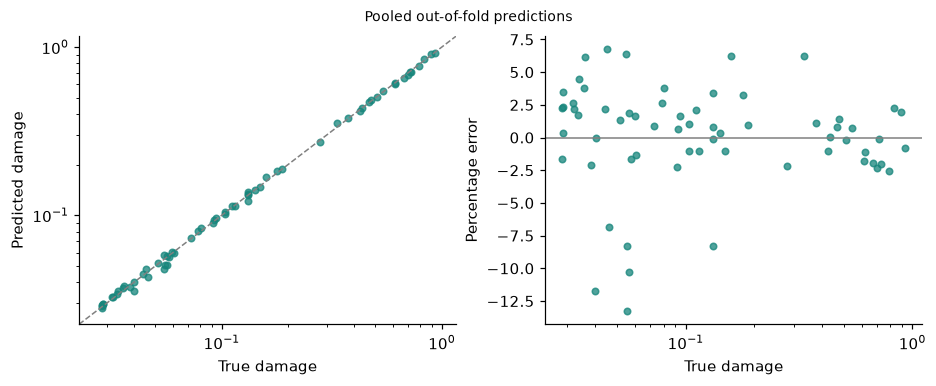

Exponent chosen in each outer fold: {np.int64(0): 5, np.int64(1): 5, np.int64(2): 5, np.int64(3): 5}


In [19]:
class PowerLawCV(FeatureModel):
    """Miner's rule with the S-N exponent chosen from the integer grid by inner leave-one-fold-out."""

    def __init__(self, m_grid):
        self.m_grid, self.features = list(m_grid), []

    def fit(self, frame):
        rows = [{'m': m, 'score': mape_score(va['damage'].to_numpy(),
                                             FixedPowerLaw(m).fit(tr).predict(va)['prediction'].to_numpy())[1]}
                for tr, va in inner_folds(frame) for m in self.m_grid]
        self.search_ = pd.DataFrame(rows)
        means = self.search_.groupby('m')['score'].mean()
        self.m_ = int(means[means == means.max()].index.min())
        self.features = [f'log10_dsum_m{self.m_}']
        self.model_ = FixedPowerLaw(self.m_).fit(frame)
        return self

    def predict(self, frame):
        return self.model_.predict(frame)


result = run_experiment('power_law', 'cv_selected_exponent', lambda: PowerLawCV(CONFIG['m_grid']),
                        params={'model': 'power_law_cv', 'm_grid': ','.join(map(str, CONFIG['m_grid']))})
show(result)
print('Exponent chosen in each outer fold:', {f: m.m_ for f, m in result['models'].items()})

<blockquote><h3 id="6-2"><b>6-2 Continuous Exponent From the Cycles</b></h3></blockquote>

The preprocessed damage sums only cover integer exponents. A per-recording lookup of the rainflow cycles lets any exponent be evaluated directly, so the exponent is optimised as a continuous value with a bounded one-dimensional search over the same inner leave-one-fold-out score, then refit by ordinary least squares as before.

fold,0,1,2,3
score,0.97999,0.970978,0.965623,0.969877


score 0.9716 (95% interval 0.9643 to 0.9783) | fold mean 0.9716 (sd 0.0060) | Spearman 0.9978 | MAPE 0.0284 | best constant 0.4402


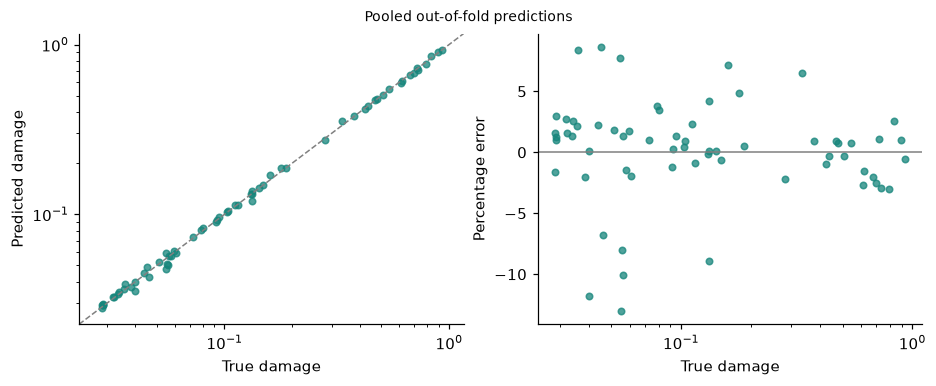

Continuous exponent chosen in each outer fold: {np.int64(0): 5.022, np.int64(1): 5.057, np.int64(2): 5.079, np.int64(3): 5.031}


In [20]:
DAMAGE = FEATURE_TABLE.set_index('file_id')['damage']
LOG_DAMAGE = FEATURE_TABLE.set_index('file_id')['log10_damage']
FOLD_OF = TRAIN.set_index('file_id')['fold']
cycles_by_file = {file_id: (g['range'].to_numpy(), g['count'].to_numpy()) for file_id, g in cycles.groupby('file_id', observed=True)}


def damage_sum(ranges, counts, m, threshold=0.0):
    """sum(count * range**m) over cycles whose range exceeds `threshold`."""
    mask = ranges > threshold
    return float(max(np.sum(counts[mask] * ranges[mask] ** m), 1e-300))


def log_dsum(file_ids, m, threshold=0.0):
    return np.array([np.log10(damage_sum(*cycles_by_file[f], m, threshold)) for f in file_ids])


class ContinuousPowerLaw:
    """Miner's rule with a continuous S-N exponent (and optional endurance threshold) fit directly from the cycles."""

    input_level = 'cycles'
    row_key = ['file_id', 'range', 'mean']
    input_columns = ['file_id', 'range', 'mean', 'count']

    def __init__(self, m_bounds, threshold_bounds=None):
        self.m_bounds, self.threshold_bounds = m_bounds, threshold_bounds

    def inner_score(self, outer_train_files, m, threshold=0.0):
        folds = FOLD_OF.loc[outer_train_files]
        scores = []
        for fold in sorted(folds.unique()):
            tr, va = folds.index[folds.ne(fold)], folds.index[folds.eq(fold)]
            slope, intercept, *_ = stats.linregress(log_dsum(tr, m, threshold), LOG_DAMAGE.loc[tr])
            pred = 10 ** (slope * log_dsum(va, m, threshold) + intercept)
            scores.append(mape_score(DAMAGE.loc[va].to_numpy(), pred)[1])
        return float(np.mean(scores))

    def fit(self, frame):
        files = frame['file_id'].unique()
        if self.threshold_bounds is None:
            res = optimize.minimize_scalar(lambda m: -self.inner_score(files, m), bounds=self.m_bounds, method='bounded',
                                           options={'xatol': 0.05})
            self.m_, self.threshold_ = float(res.x), 0.0
        else:
            res = optimize.minimize(lambda p: -self.inner_score(files, p[0], p[1]), x0=[5.0, 0.0], method='Nelder-Mead',
                                    bounds=[self.m_bounds, self.threshold_bounds],
                                    options={'xatol': 0.02, 'fatol': 1e-4, 'maxiter': 60})
            self.m_, self.threshold_ = float(res.x[0]), float(res.x[1])
        x = log_dsum(files, self.m_, self.threshold_)
        self.slope_, self.intercept_, *_ = stats.linregress(x, LOG_DAMAGE.loc[files])
        return self

    def predict(self, frame):
        files = frame['file_id'].unique()
        x = log_dsum(files, self.m_, self.threshold_)
        return pd.DataFrame({'file_id': files, 'prediction': 10 ** (self.slope_ * x + self.intercept_)})


result = run_experiment('power_law', 'continuous_exponent', lambda: ContinuousPowerLaw(CONFIG['m_bounds']),
                        params={'model': 'continuous_power_law', 'm_bounds': str(CONFIG['m_bounds'])})
show(result)
print('Continuous exponent chosen in each outer fold:', {f: round(m.m_, 3) for f, m in result['models'].items()})

<blockquote><h3 id="6-3"><b>6-3 Exponent and Endurance Threshold</b></h3></blockquote>

Real S-N curves sometimes have an endurance limit below which cycles cause no measurable damage. This variant searches jointly over the exponent and a range threshold below which cycles are dropped from the sum entirely, to see whether an explicit cutoff improves on letting the exponent alone suppress small cycles.

In [21]:
result = run_experiment('power_law', 'exponent_and_threshold',
                        lambda: ContinuousPowerLaw(CONFIG['m_bounds'], CONFIG['threshold_bounds']),
                        params={'model': 'continuous_power_law_threshold', 'm_bounds': str(CONFIG['m_bounds']),
                                'threshold_bounds': str(CONFIG['threshold_bounds'])}, role='variant')
show(result, figure=False)
print('(exponent, threshold) chosen in each outer fold:', {f: (round(m.m_, 3), round(m.threshold_, 3)) for f, m in result['models'].items()})
display(score_table([('power_law', n) for n in ['cv_selected_exponent', 'continuous_exponent', 'exponent_and_threshold']]).round(4))

fold,0,1,2,3
score,0.980241,0.971015,0.966559,0.96988


score 0.9719 (95% interval 0.9647 to 0.9786) | fold mean 0.9719 (sd 0.0059) | Spearman 0.9978 | MAPE 0.0281 | best constant 0.4402
(exponent, threshold) chosen in each outer fold: {np.int64(0): (5.031, 0.0), np.int64(1): (5.047, 0.0), np.int64(2): (5.062, 0.0), np.int64(3): (5.031, 0.0)}


,score,MAPE
power_law / cv_selected_exponent,0.9720,0.0280
power_law / continuous_exponent,0.9716,0.0284
power_law / exponent_and_threshold,0.9719,0.0281


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Regularised Linear Model</b></h2>
</div>

A single damage sum cannot use the signal statistics or the range-distribution features at all. The first model to see every feature combines all 39 into one linear score, standardised and regularised so that the weak features are shrunk towards zero rather than adding noise. Its runs are recorded in the experiment `shm_elastic_net`: the full model, four feature-group ablations, and the fitted coefficients.

<blockquote><h3 id="7-1"><b>7-1 Elastic Net Regressor</b></h3></blockquote>

Features are standardised with constants from the training recordings, and log10 damage is regressed with an elastic net penalty (`l1_ratio = 0.5`, a balance of ridge and lasso shrinkage). The penalty strength `alpha` is chosen from a grid by an inner leave-one-fold-out loop on the training folds, and ties go to the largest value, the strongest regularisation.

In [22]:
class ElasticNetDamage(FeatureModel):
    """Standardised elastic net regression of log10 damage; alpha chosen by inner leave-one-fold-out."""

    def __init__(self, features, alpha_grid, l1_ratio):
        self.features, self.alpha_grid, self.l1_ratio = list(features), list(alpha_grid), l1_ratio

    def fit_fixed(self, frame, alpha):
        self.scaler_ = StandardScaler().fit(frame[self.features])
        X = self.scaler_.transform(frame[self.features])
        self.model_ = ElasticNet(alpha=alpha, l1_ratio=self.l1_ratio, max_iter=20000, random_state=SEED)
        self.model_.fit(X, frame['log10_damage'])
        self.alpha_ = alpha
        return self

    def fit(self, frame):
        rows = [{'alpha': alpha, 'score': mape_score(
                    va['damage'].to_numpy(),
                    ElasticNetDamage(self.features, [alpha], self.l1_ratio).fit_fixed(tr, alpha).predict(va)['prediction'].to_numpy()
                 )[1]}
                for tr, va in inner_folds(frame) for alpha in self.alpha_grid]
        self.search_ = pd.DataFrame(rows)
        means = self.search_.groupby('alpha')['score'].mean()
        best_alpha = means[means == means.max()].index.max()  # ties -> largest alpha, the strongest regularisation
        return self.fit_fixed(frame, best_alpha)

    def predict(self, frame):
        X = self.scaler_.transform(frame[self.features])
        return self.output(frame, 10 ** self.model_.predict(X))


def elasticnet_params(features):
    return {'model': 'elastic_net', 'features': ','.join(features), 'n_features': len(features),
            'alpha_grid': ','.join(map(str, CONFIG['alpha_grid'])), 'l1_ratio': CONFIG['l1_ratio']}


def elasticnet_tables(result):
    """Fitted coefficients and chosen alpha of every fold."""
    coefs = pd.DataFrame({fold: pd.Series(m.model_.coef_, index=m.features) for fold, m in result['models'].items()}).T
    return {'fold_coefficients': coefs.assign(alpha=[m.alpha_ for m in result['models'].values()])}

<blockquote><h3 id="7-2"><b>7-2 All Features</b></h3></blockquote>

The full model uses all 39 features of Section 2.4 and is the candidate from this architecture.

fold,0,1,2,3
score,0.984936,0.977152,0.973681,0.972132


score 0.9770 (95% interval 0.9729 to 0.9810) | fold mean 0.9770 (sd 0.0057) | Spearman 0.9983 | MAPE 0.0230 | best constant 0.4402


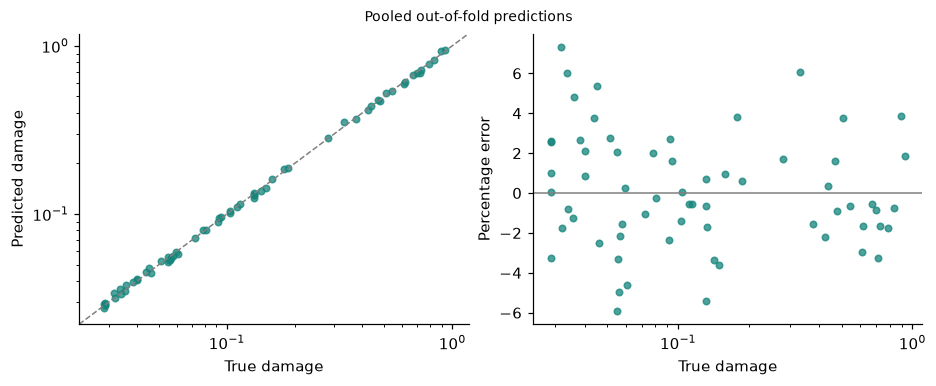

In [23]:
result = run_experiment('elastic_net', 'all_features', lambda: ElasticNetDamage(FEATURES, CONFIG['alpha_grid'], CONFIG['l1_ratio']),
                        params=elasticnet_params(FEATURES), tables=elasticnet_tables)
show(result)

<blockquote><h3 id="7-3"><b>7-3 Feature-Group Ablations</b></h3></blockquote>

Each ablation isolates or removes one group of features to show which evidence the model relies on: damage sums and equivalent ranges alone, signal statistics alone, range-distribution features alone, and everything except the damage sums and equivalent ranges. These runs are diagnostics and do not compete in the comparison.

In [24]:
ABLATIONS = {
    'damage_sum_only': GROUPS['damage sum'] + GROUPS['equivalent range'],
    'signal_only': GROUPS['signal'],
    'range_distribution_only': GROUPS['range distribution'],
    'without_damage_sum': GROUPS['signal'] + GROUPS['range distribution'],
}
for name, feats in ABLATIONS.items():
    run_experiment('elastic_net', name, lambda feats=feats: ElasticNetDamage(feats, CONFIG['alpha_grid'], CONFIG['l1_ratio']),
                  params=elasticnet_params(feats), role='variant')
display(score_table([('elastic_net', 'all_features')] + [('elastic_net', n) for n in ABLATIONS]).round(4))

,score,MAPE
elastic_net / all_features,0.9770,0.0230
elastic_net / damage_sum_only,0.9747,0.0253
elastic_net / signal_only,0.7525,0.2475
elastic_net / range_distribution_only,0.4198,0.5802
elastic_net / without_damage_sum,0.8268,0.1732


<blockquote><h3 id="7-4"><b>7-4 Coefficients</b></h3></blockquote>

The coefficients of the full model in each fold, averaged and sorted by magnitude, show which features carry the score; coefficients apply to standardised features, so their sizes are comparable. The last column is the chosen `alpha`.

In [25]:
fold_coefficients = elasticnet_tables(RESULTS[('elastic_net', 'all_features')])['fold_coefficients']
mean_abs = fold_coefficients.drop(columns='alpha').abs().mean().sort_values(ascending=False)
display(fold_coefficients[list(mean_abs.head(12).index) + ['alpha']].round(4))

,log10_dsum_m4,log10_dsum_m5,log10_dsum_m6,log10_dsum_m7,log10_dsum_m8,eq_range_m5,eq_range_m4,peak_to_peak,log10_dsum_m9,skewness,log10_dsum_m3,std,alpha
0,0.1382,0.1364,0.0971,0.0532,0.0206,0.0145,0.0042,0.0234,0.0038,-0.0039,0.0000,0.0012,0.003
1,0.1241,0.1197,0.0906,0.0589,0.0302,0.0245,0.0188,0.0069,0.0105,-0.0052,0.0000,0.0000,0.003
2,0.1174,0.1214,0.0975,0.0627,0.0298,0.0106,0.0232,0.0121,0.0087,-0.0038,0.0048,0.0048,0.003
3,0.1238,0.1113,0.0833,0.0564,0.0302,0.0299,0.0138,0.0126,0.0097,-0.0015,0.0081,0.0043,0.003


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Gradient Boosting</b></h2>
</div>

A linear score cannot represent thresholds or interactions between features. Gradient-boosted trees can, at the cost of needing more data than the 48 recordings available per training fold; the trees are kept very small to compensate. Its runs are recorded in the experiment `shm_gradient_boosting`.

<blockquote><h3 id="8-1"><b>8-1 LightGBM Regressor</b></h3></blockquote>

The trees are limited to four leaves and at least five recordings per leaf, with 150 rounds at a learning rate of 0.05, 80% of the recordings and half of the features sampled for each tree. By default the target is log10 damage, as for every other architecture; setting `objective='mape'` instead trains LightGBM's own MAPE-minimising objective directly on the raw damage scale.

In [26]:
class LightGBMDamage(FeatureModel):
    """LightGBM regressor; predicts log10 damage unless `objective='mape'`, which predicts damage directly."""

    def __init__(self, features, params, objective='regression'):
        self.features, self.params, self.objective = list(features), dict(params), objective

    def fit(self, frame):
        target = frame['damage'] if self.objective == 'mape' else frame['log10_damage']
        self.model_ = lgb.LGBMRegressor(objective=self.objective, random_state=SEED, verbose=-1, **self.params)
        self.model_.fit(frame[self.features], target)
        return self

    def predict(self, frame):
        raw = self.model_.predict(frame[self.features])
        return self.output(frame, raw if self.objective == 'mape' else 10 ** raw)


def lgbm_params(features, objective='regression'):
    return {'model': 'lightgbm', 'objective': objective, 'features': ','.join(features), 'n_features': len(features),
            **CONFIG['lightgbm']}

<blockquote><h3 id="8-2"><b>8-2 All Features</b></h3></blockquote>

The model on all 39 features, predicting log10 damage, is the candidate from this architecture.

fold,0,1,2,3
score,0.921255,0.913484,0.908456,0.938712


score 0.9205 (95% interval 0.9003 to 0.9383) | fold mean 0.9205 (sd 0.0132) | Spearman 0.9919 | MAPE 0.0795 | best constant 0.4402


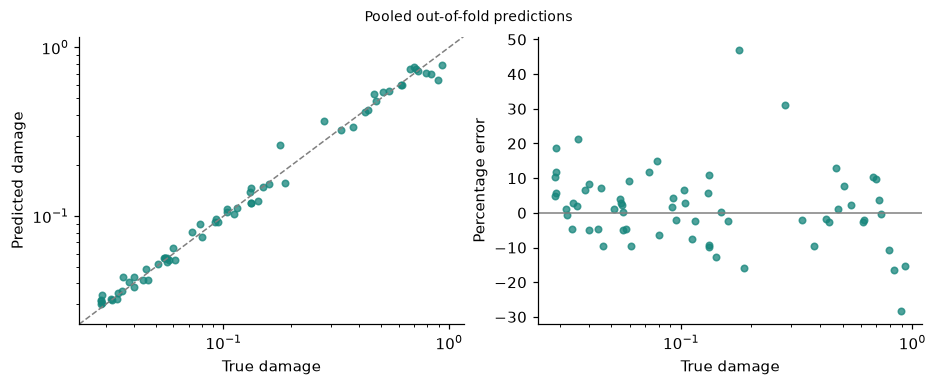

In [27]:
result = run_experiment('gradient_boosting', 'all_features', lambda: LightGBMDamage(FEATURES, CONFIG['lightgbm']),
                        params=lgbm_params(FEATURES))
show(result)

<blockquote><h3 id="8-3"><b>8-3 Without Damage-Sum Features</b></h3></blockquote>

As for the elastic net, one variant drops the damage sums and equivalent ranges to see how well the trees do from signal and range-distribution features alone, without the features that already encode Miner's rule.

In [28]:
run_experiment('gradient_boosting', 'without_damage_sum',
              lambda: LightGBMDamage(GROUPS['signal'] + GROUPS['range distribution'], CONFIG['lightgbm']),
              params=lgbm_params(GROUPS['signal'] + GROUPS['range distribution']), role='variant')

{'split': 'damage-band-stratified-4-fold',
 'predictions':         file_id  prediction    damage  damage_band  fold
 0   train03.csv    0.086853  0.111298            2     0
 1   train13.csv    0.037135  0.028620            0     0
 2   train17.csv    0.484304  0.423559            3     0
 3   train20.csv    0.151950  0.115031            2     0
 4   train22.csv    0.072213  0.080671            1     0
 5   train25.csv    0.046051  0.057599            1     0
 6   train32.csv    0.050924  0.059656            1     0
 7   train35.csv    0.032057  0.028828            0     0
 8   train37.csv    0.587457  0.507868            3     0
 9   train39.csv    0.485096  0.542142            3     0
 10  train51.csv    0.136000  0.131488            2     0
 11  train53.csv    0.043794  0.043913            0     0
 12  train54.csv    0.536115  0.832608            3     0
 13  train62.csv    0.039333  0.046122            1     0
 14  train63.csv    0.032409  0.032083            0     0
 15  train64.c

<blockquote><h3 id="8-4"><b>8-4 MAPE Objective</b></h3></blockquote>

This variant keeps all 39 features but trains on the raw damage scale with LightGBM's `mape` objective, to see whether optimising a loss close to the evaluation metric beats the log-space model above.

In [29]:
run_experiment('gradient_boosting', 'mape_objective', lambda: LightGBMDamage(FEATURES, CONFIG['lightgbm'], objective='mape'),
              params=lgbm_params(FEATURES, 'mape'), role='variant')
display(score_table([('gradient_boosting', n) for n in ['all_features', 'without_damage_sum', 'mape_objective']]).round(4))

,score,MAPE
gradient_boosting / all_features,0.9205,0.0795
gradient_boosting / without_damage_sum,0.7803,0.2197
gradient_boosting / mape_objective,0.8802,0.1198


<blockquote><h3 id="8-5"><b>8-5 Feature Importance</b></h3></blockquote>

The total gain of each feature, averaged over the four folds, shows which features the trees split on most. The table lists the fifteen largest.

In [30]:
gain = pd.DataFrame({fold: pd.Series(m.model_.booster_.feature_importance('gain'), index=m.features)
                     for fold, m in RESULTS[('gradient_boosting', 'all_features')]['models'].items()})
display(gain.mean(axis=1).sort_values(ascending=False).head(15).rename('mean gain').to_frame().round(1))

,mean gain
log10_dsum_m5,31.0
peak_to_peak,12.8
log10_dsum_m3,10.3
log10_dsum_m6,8.2
log10_dsum_m4,6.1
eq_range_m4,5.8
log10_dsum_m8,4.5
eq_range_m6,2.6
eq_range_m5,2.4
log10_dsum_m7,2.4


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Nonparametric Damage-Rate Curve</b></h2>
</div>

Every earlier architecture assumes damage grows as a power of the cycle range, an assumption borrowed from the exploratory analysis rather than learned. This architecture works one level below the feature table, directly on the rainflow cycles, and learns how much a cycle of a given range contributes to damage as a smooth, monotonically increasing curve, with no exponent assumed at all: Miner's rule becomes one special case the curve is free to reproduce, not a constraint built into it. Its runs are recorded in the experiment `shm_damage_curve`.

<blockquote><h3 id="9-1"><b>9-1 Log-Range Histograms</b></h3></blockquote>

The curve is represented by its height at a fixed grid of knots, evenly spaced in log10 range from the smallest to the largest cycle range in the dataset. Every cycle is split between its two neighbouring knots by linear interpolation and weighted by its count, so each recording is summarised by one vector of knot weights; a recording's damage is then a linear function of the curve's height at every knot. This hat, or tent-function, basis places each cycle at its exact log-range instead of rounding it into a histogram bin, which preprocessing's own bins were not built to preserve.

In [31]:
LOG_RANGE_MIN, LOG_RANGE_MAX = np.log10(cycles['range'].min()), np.log10(cycles['range'].max())


def build_hat_design(file_ids, knots):
    """Per-recording vector of count-weighted linear (hat) interpolation weights onto `knots` (log10 range)."""
    H = np.zeros((len(file_ids), len(knots)))
    for i, f in enumerate(file_ids):
        ranges, counts = cycles_by_file[f]
        x = np.log10(ranges)
        j = np.clip(np.searchsorted(knots, x, side='right') - 1, 0, len(knots) - 2)
        frac = np.clip((x - knots[j]) / (knots[j + 1] - knots[j]), 0.0, 1.0)
        np.add.at(H[i], j, counts * (1 - frac))
        np.add.at(H[i], j + 1, counts * frac)
    return H


demo_knots = np.linspace(LOG_RANGE_MIN, LOG_RANGE_MAX, 6)
demo = pd.DataFrame(build_hat_design(['train01.csv', 'train64.csv'], demo_knots), index=['train01.csv', 'train64.csv'],
                    columns=[f'{10**k:.3f}' for k in demo_knots])
display(demo.round(1))

,0.004,0.032,0.235,1.743,12.947,96.201
train01.csv,1439.3,4975.1,70259.7,97342.6,5121.8,29.6
train64.csv,521.5,6627.6,79820.8,73552.3,4629.9,55.0


<blockquote><h3 id="9-2"><b>9-2 Monotonic Damage-Rate Ranker</b></h3></blockquote>

The curve's height at knot `k` is the cumulative sum of non-negative increments, so it can only increase with range, as a physical damage rate must. The increments are optimised in log space so that they stay non-negative without a hard constraint, minimising the squared relative error of the predicted damage plus a penalty on the curvature of the log increments; that penalty is what keeps a curve with dozens of knots from overfitting 48 training recordings; it lets the curve settle close to a straight line in log-log space, a power law, unless the data clearly demands otherwise. The penalty strength `lambda` is chosen by the same inner leave-one-fold-out loop as every other tuned model.

In [32]:
def second_diff_matrix(n):
    """(n-2, n) discrete second-difference (curvature) operator."""
    D = np.zeros((n - 2, n))
    idx = np.arange(n - 2)
    D[idx, idx], D[idx, idx + 1], D[idx, idx + 2] = 1, -2, 1
    return D


def fit_damage_curve(H_train, damage_train, lam, knots, m_init=5.0, maxiter=300):
    """Monotonic damage-rate curve w(range) minimising relative squared error, penalised on its curvature."""
    n_knots = len(knots)
    L = np.tril(np.ones((n_knots, n_knots)))
    A = H_train / damage_train[:, None]
    D = second_diff_matrix(n_knots)
    w0 = 10 ** (m_init * knots)  # warm start: a plain m=5 power law
    v0 = np.maximum(np.diff(np.concatenate([[0.0], w0 / w0[-1]])), 1e-12)
    theta0 = np.log(v0)
    theta0 = theta0 - np.log(max(np.mean(A @ (L @ np.exp(theta0))), 1e-300))

    def loss_grad(theta):
        v = np.exp(theta)
        w = L @ v
        resid = A @ w - 1.0
        d_theta = D @ theta
        loss = np.sum(resid ** 2) + lam * np.sum(d_theta ** 2)
        grad_v = L.T @ (2 * (A.T @ resid))
        grad_theta = grad_v * v + 2 * lam * (D.T @ d_theta)
        return loss, grad_theta

    theta = optimize.minimize(loss_grad, theta0, jac=True, method='L-BFGS-B', options={'maxiter': maxiter}).x
    return L @ np.exp(theta)


class DamageCurveRanker:
    """Learns a smooth, monotonically increasing damage-rate curve over log cycle range, generalising Miner's rule."""

    input_level = 'cycles'
    row_key = ['file_id', 'range', 'mean']
    input_columns = ['file_id', 'range', 'mean', 'count']

    def __init__(self, n_knots, lambda_grid, m_init=5.0):
        self.n_knots, self.lambda_grid, self.m_init = n_knots, list(lambda_grid), m_init
        self.knots = np.linspace(LOG_RANGE_MIN, LOG_RANGE_MAX, n_knots)
        all_files = FEATURE_TABLE['file_id'].tolist()
        self.design_ = dict(zip(all_files, build_hat_design(all_files, self.knots)))

    def curve(self, files, damage, lam):
        return fit_damage_curve(np.array([self.design_[f] for f in files]), damage, lam, self.knots, self.m_init)

    def score_with(self, files, w):
        pred = np.array([self.design_[f] for f in files]) @ w
        return mape_score(DAMAGE.loc[files].to_numpy(), pred)[1]

    def fit(self, frame):
        files = frame['file_id'].unique()
        folds = FOLD_OF.loc[files]
        scores = {}
        for lam in self.lambda_grid:
            inner = []
            for fold in sorted(folds.unique()):
                tr, va = folds.index[folds.ne(fold)], folds.index[folds.eq(fold)]
                w = self.curve(tr, DAMAGE.loc[tr].to_numpy(), lam)
                inner.append(self.score_with(va, w))
            scores[lam] = float(np.mean(inner))
        self.search_ = pd.Series(scores, name='score').rename_axis('lambda')
        self.lambda_ = float(self.search_[self.search_ == self.search_.max()].index.max())
        self.w_ = self.curve(files, DAMAGE.loc[files].to_numpy(), self.lambda_)
        return self

    def predict(self, frame):
        files = frame['file_id'].unique()
        return pd.DataFrame({'file_id': files, 'prediction': np.array([self.design_[f] for f in files]) @ self.w_})

<blockquote><h3 id="9-3"><b>9-3 All Recordings</b></h3></blockquote>

The curve at 40 knots, chosen so that the grid resolves the top of the range distribution without giving the optimiser more free knots than are needed, is the candidate from this architecture.

fold,0,1,2,3
score,0.97374,0.96848,0.975459,0.963046


score 0.9702 (95% interval 0.9624 to 0.9773) | fold mean 0.9702 (sd 0.0056) | Spearman 0.9976 | MAPE 0.0298 | best constant 0.4402


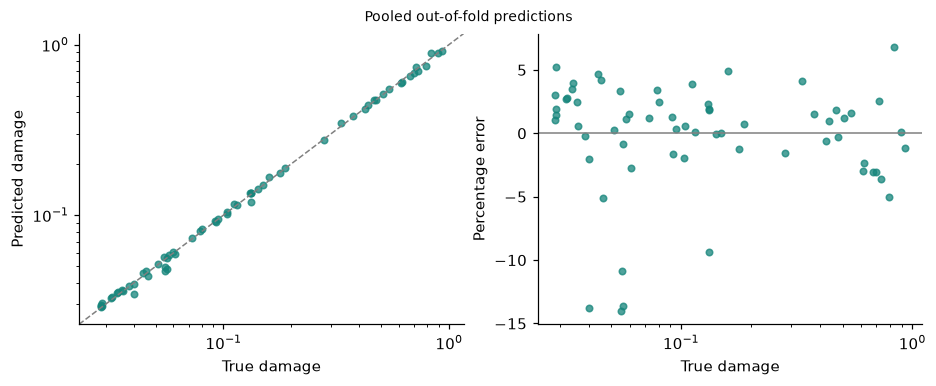

Penalty strength chosen in each outer fold: {np.int64(0): 1.0, np.int64(1): 0.3, np.int64(2): 1.0, np.int64(3): 0.1}


In [33]:
result = run_experiment('damage_curve', 'all_recordings', lambda: DamageCurveRanker(CONFIG['curve_knots'], CONFIG['curve_lambda_grid']),
                        params={'model': 'damage_rate_curve', 'n_knots': CONFIG['curve_knots'],
                                'lambda_grid': ','.join(map(str, CONFIG['curve_lambda_grid']))})
show(result)
print('Penalty strength chosen in each outer fold:', {f: m.lambda_ for f, m in result['models'].items()})

<blockquote><h3 id="9-4"><b>9-4 Learned Curve Shape</b></h3></blockquote>

The curve fitted in each fold, normalised to 1 at the largest range, shows what the model learned without being told an exponent: the local slope in log-log space, away from the negligible low-range tail, can be compared directly with the m = 5 line of Section 5.2.

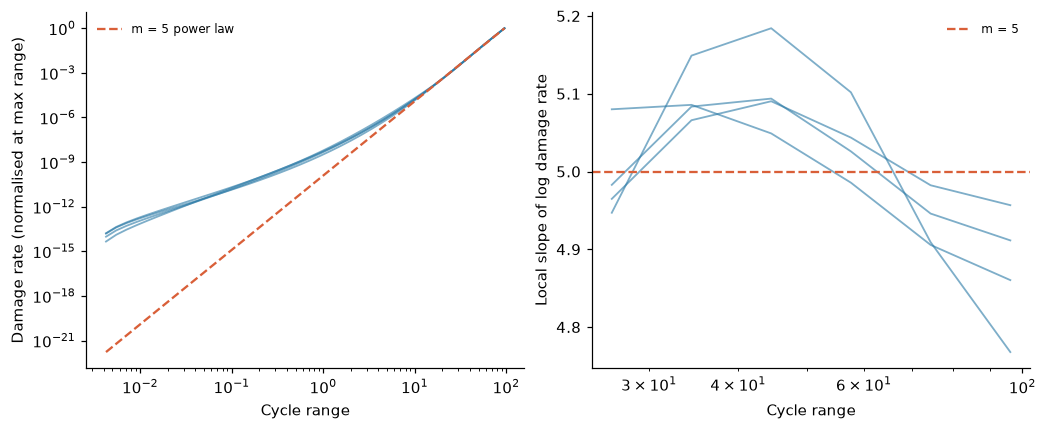

,range where the curve is non-negligible (w > 0.1% of max),effective local slope there
fold,,
0,26.6+,5.02
1,26.6+,4.99
2,26.6+,5.01
3,26.6+,5.01


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8))
knots = result['models'][FOLD_IDS[0]].knots
ranges = 10 ** knots
for fold, model in result['models'].items():
    axes[0].plot(ranges, model.w_ / model.w_[-1], color=COLORS['candidate'], alpha=0.6, linewidth=1.2)
axes[0].plot(ranges, (ranges / ranges[-1]) ** 5, color=COLORS['accent'], linestyle='--', linewidth=1.5, label='m = 5 power law')
axes[0].set(xscale='log', yscale='log', xlabel='Cycle range', ylabel='Damage rate (normalised at max range)')
axes[0].legend(frameon=False, fontsize=8)

slope_rows = []
for fold, model in result['models'].items():
    w_norm = model.w_ / model.w_[-1]
    local_slope = np.gradient(np.log10(np.maximum(model.w_, 1e-300)), model.knots)
    relevant = w_norm > 1e-3
    slope_rows.append({'fold': fold, 'range where the curve is non-negligible (w > 0.1% of max)': f'{ranges[relevant][0]:.1f}+',
                       'effective local slope there': f'{local_slope[relevant].mean():.2f}'})
    axes[1].plot(ranges[relevant], local_slope[relevant], color=COLORS['candidate'], alpha=0.6, linewidth=1.2)
axes[1].axhline(5, color=COLORS['accent'], linestyle='--', linewidth=1.5, label='m = 5')
axes[1].set(xscale='log', xlabel='Cycle range', ylabel='Local slope of log damage rate')
axes[1].legend(frameon=False, fontsize=8)
plt.show()
display(pd.DataFrame(slope_rows).set_index('fold'))

<blockquote><h3 id="9-5"><b>9-5 Knot-Count Sensitivity</b></h3></blockquote>

Two variants repeat the fit with fewer and more knots, to check that 40 was not a lucky choice: too few knots cannot resolve the range distribution's extreme tail, where nearly all the damage lives, and the score should recover as the grid is refined.

In [35]:
for nk in [16, 64]:
    run_experiment('damage_curve', f'{nk}_knots', lambda nk=nk: DamageCurveRanker(nk, CONFIG['curve_lambda_grid']),
                  params={'model': 'damage_rate_curve', 'n_knots': nk,
                          'lambda_grid': ','.join(map(str, CONFIG['curve_lambda_grid']))}, role='variant')
display(score_table([('damage_curve', n) for n in ['all_recordings', '16_knots', '64_knots']]).round(4))

,score,MAPE
damage_curve / all_recordings,0.9702,0.0298
damage_curve / 16_knots,0.9075,0.0925
damage_curve / 64_knots,0.9718,0.0282


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Model Comparison</b></h2>
</div>

This section puts all architectures side by side, using the runs as recorded in MLflow, and selects the model to carry forward.

<blockquote><h3 id="10-1"><b>10-1 Results Across Experiments</b></h3></blockquote>

The runs of this execution are read back from the tracking server by their `notebook_run` tag, so the comparison uses exactly what was recorded. The table lists every run in the order it was built, with its pooled score, the bootstrap interval, the MAPE and the Spearman correlation.

In [36]:
EXPERIMENTS = [f'shm_{arch}' for arch in dict.fromkeys(arch for arch, _ in RESULTS)]
LABELS = [f'{arch} / {name}' for arch, name in RESULTS]
experiment_names = {experiment_id(name): name.removeprefix('shm_') for name in EXPERIMENTS}
runs = mlflow.search_runs(experiment_names=EXPERIMENTS, filter_string=f"tags.notebook_run = '{NOTEBOOK_RUN}'")
runs.index = runs['experiment_id'].map(experiment_names) + ' / ' + runs['tags.mlflow.runName']
runs = runs[runs['tags.role'].ne('final')].reindex(LABELS)
assert runs['run_id'].notna().all(), 'Some runs of this execution were not found on the tracking server.'
COMPARISON = pd.DataFrame({'role': runs['tags.role'], 'score': runs['metrics.score'], 'MAPE': runs['metrics.mape'],
                           'CI low': runs['metrics.score_ci_low'], 'CI high': runs['metrics.score_ci_high'],
                           'Spearman': runs['metrics.spearman']})
display(COMPARISON.round(4))

,role,score,MAPE,CI low,CI high,Spearman
baseline / optimal_constant,candidate,0.4370,0.5630,0.4082,0.4653,0.0169
baseline / miners_rule_m5,candidate,0.9720,0.0280,0.9653,0.9782,0.9977
power_law / cv_selected_exponent,candidate,0.9720,0.0280,0.9653,0.9782,0.9977
power_law / continuous_exponent,candidate,0.9716,0.0284,0.9643,0.9783,0.9978
power_law / exponent_and_threshold,variant,0.9719,0.0281,0.9647,0.9786,0.9978
elastic_net / all_features,candidate,0.9770,0.0230,0.9729,0.9810,0.9983
elastic_net / damage_sum_only,variant,0.9747,0.0253,0.9700,0.9792,0.9981
elastic_net / signal_only,variant,0.7525,0.2475,0.6950,0.8025,0.9538
elastic_net / range_distribution_only,variant,0.4198,0.5802,0.3069,0.5265,0.7323
elastic_net / without_damage_sum,variant,0.8268,0.1732,0.7885,0.8606,0.9627


<blockquote><h3 id="10-2"><b>10-2 Comparison Plot</b></h3></blockquote>

The plot shows the pooled score of every run with its bootstrap interval. Candidates, one per architecture plus the two exponent extensions of Section 6, are coloured; diagnostic variants are grey. The dashed line is the score of the best constant prediction.

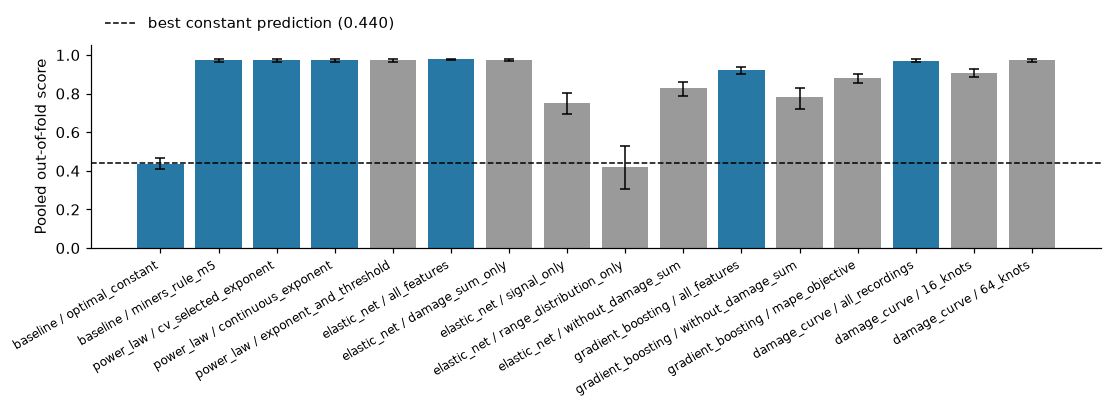

In [37]:
comparison_figure(COMPARISON)
plt.show()

<blockquote><h3 id="10-3"><b>10-3 Model Selection</b></h3></blockquote>

The selected model is the candidate with the highest pooled score. When candidates tie, the simplest wins, following the order in which the architectures were built, since added complexity has to earn its place. Two points limit what the comparison can show. With 64 recordings in 4 folds, the bootstrap intervals of the leading candidates overlap substantially, so the data cannot decisively separate them. And the features and the exponent were both explored with all 64 labels in view during preprocessing, so every score is an optimistic development estimate rather than an independent test.

In [38]:
candidates = COMPARISON[COMPARISON['role'].eq('candidate')]
best = candidates.index[np.isclose(candidates['score'], candidates['score'].max())].tolist()
SELECTED = list(RESULTS)[LABELS.index(best[0])]
client.set_tag(RESULTS[SELECTED]['run_id'], 'selected', 'true')
display(candidates[['score', 'CI low', 'CI high', 'MAPE']].assign(selected=candidates.index == best[0]).round(4))
print('Selected:', best[0], '| other candidates with the same score:', ', '.join(best[1:]) or 'none')

,score,CI low,CI high,MAPE,selected
baseline / optimal_constant,0.4370,0.4082,0.4653,0.5630,False
baseline / miners_rule_m5,0.9720,0.9653,0.9782,0.0280,False
power_law / cv_selected_exponent,0.9720,0.9653,0.9782,0.0280,False
power_law / continuous_exponent,0.9716,0.9643,0.9783,0.0284,False
elastic_net / all_features,0.9770,0.9729,0.9810,0.0230,True
gradient_boosting / all_features,0.9205,0.9003,0.9383,0.0795,False
damage_curve / all_recordings,0.9702,0.9624,0.9773,0.0298,False


Selected: elastic_net / all_features | other candidates with the same score: none


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-11" style="color: black;"><b>Section 11: Final Model</b></h2>
</div>

This section refits the selected configuration on all Train recordings, packages it as an MLflow model with input checks, registers it, and predicts the damage of the Test recordings.

<blockquote><h3 id="11-1"><b>11-1 Refit on All Train Recordings</b></h3></blockquote>

The selected configuration is fitted on all 64 Train recordings in a run named `final_refit`, inside the experiment of its architecture and linked to the evaluation run it came from. No score is reported for the refit, because it would be measured on the recordings it was fitted on.

In [39]:
ARCH, NAME = SELECTED
chosen = RESULTS[SELECTED]
FINAL_MODEL = chosen['make_model']()
start = time.perf_counter()
FINAL_MODEL.fit(frame_for(FINAL_MODEL.input_level, TRAIN['file_id']))
fit_seconds = time.perf_counter() - start
with mlflow.start_run(experiment_id=experiment_id(f'shm_{ARCH}'), run_name='final_refit',
                      tags={'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'role': 'final',
                            'evaluation_run_id': chosen['run_id']}) as final_run:
    mlflow.log_params({**chosen['params'], 'training_recordings': len(TRAIN), 'seed': SEED})
    mlflow.log_metric('fit_time_s', fit_seconds)
FINAL_RUN_ID = final_run.info.run_id
display(pd.Series({'experiment': f'shm_{ARCH}', 'configuration': NAME, **chosen['params']}, name='value').to_frame())

,value
experiment,shm_elastic_net
configuration,all_features
model,elastic_net
features,"mean,std,peak_to_peak,skewness,kurtosis,diff_r..."
n_features,39
alpha_grid,"0.003,0.01,0.03,0.1,0.3,1.0"
l1_ratio,0.5


<blockquote><h3 id="11-2"><b>11-2 Model Package</b></h3></blockquote>

The fitted model is wrapped as an MLflow Python model. Its input is one row of recording features per recording for the feature-level architectures, or the raw rainflow cycles for the two that read them, always with `file_id`. The wrapper rejects missing columns, repeated rows and infinite values, and returns each recording's predicted damage. The example below is five Train recordings.

In [40]:
class ShmDamagePackage(mlflow.pyfunc.PythonModel):
    """Checks the input table, then predicts cumulative fatigue damage for every recording in it."""

    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input: pd.DataFrame, params=None) -> pd.DataFrame:
        frame = pd.DataFrame(model_input)
        missing = [c for c in self.model.input_columns if c not in frame.columns]
        if missing:
            raise ValueError(f'Missing required columns: {missing}')
        if frame.duplicated(self.model.row_key).any():
            raise ValueError(f'Rows must be unique by {self.model.row_key}.')
        if np.isinf(frame[self.model.input_columns].select_dtypes('number').to_numpy(dtype=float)).any():
            raise ValueError('Values must be finite or missing.')
        return self.model.predict_table(frame[self.model.input_columns])


def model_input(file_ids):
    """Package input for the given recordings, in the form the final model expects."""
    file_ids = list(file_ids)
    if FINAL_MODEL.input_level == 'features':
        return FEATURE_TABLE.set_index('file_id').loc[file_ids].reset_index()[FINAL_MODEL.input_columns]
    return cycles[cycles['file_id'].isin(file_ids)][FINAL_MODEL.input_columns]


PACKAGE = ShmDamagePackage(FINAL_MODEL)
EXAMPLE = model_input(TRAIN['file_id'].head(1 if FINAL_MODEL.input_level == 'cycles' else 5))
SIGNATURE = infer_signature(EXAMPLE, PACKAGE.predict(None, EXAMPLE))
display(PACKAGE.predict(None, EXAMPLE))

,file_id,prediction
0,train01.csv,0.104523
1,train02.csv,0.144704
2,train03.csv,0.110861
3,train04.csv,0.922623
4,train05.csv,0.055185


<blockquote><h3 id="11-3"><b>11-3 Registration</b></h3></blockquote>

The package is logged to the `final_refit` run with its signature, an input example and pinned requirements, and registered as a new version of `shm_damage_regressor` with a short description. The new version receives the `champion` alias. The model is serialised with cloudpickle because it is defined in this notebook.

In [41]:
PINS = [f'{n}=={importlib.metadata.version(n)}' for n in
        ['mlflow', 'numpy', 'pandas', 'scikit-learn', 'lightgbm', 'scipy', 'cloudpickle']]
DESCRIPTION = (f"Predicts cumulative fatigue damage for an SHM stress recording. Configuration {ARCH} / {NAME}, refitted "
              f"on the 64 Train recordings; pooled out-of-fold score {chosen['summary']['score']:.3f} "
              f"(MAPE {chosen['summary']['mape']:.3f}) on the four damage-band folds.")
pyfunc_logger = logging.getLogger('mlflow.pyfunc')
previous_level = pyfunc_logger.level
pyfunc_logger.setLevel(logging.ERROR)  # silences the notice about pickled models, which are produced here
try:
    with mlflow.start_run(run_id=FINAL_RUN_ID):
        MODEL_INFO = mlflow.pyfunc.log_model(name='model', python_model=PACKAGE, signature=SIGNATURE,
                                             input_example=EXAMPLE, pip_requirements=PINS)
finally:
    pyfunc_logger.setLevel(previous_level)
with contextlib.redirect_stderr(io.StringIO()):
    MODEL_VERSION = mlflow.register_model(MODEL_INFO.model_uri, CONFIG['registered_model']).version
client.update_model_version(CONFIG['registered_model'], MODEL_VERSION, description=DESCRIPTION)
client.set_registered_model_alias(CONFIG['registered_model'], 'champion', MODEL_VERSION)
print(f"Registered {CONFIG['registered_model']} version {MODEL_VERSION} with alias champion.")

Registered shm_damage_regressor version 1 with alias champion.


<blockquote><h3 id="11-4"><b>11-4 Submission Format</b></h3></blockquote>

The submission file `shm_predictions.csv` has one row per Test recording: `file_id`, the recording's file name with its extension, and `prediction`, a single positive damage value. The validator is tested on two malformed tables.

In [42]:
def export_rows(predicted):
    """One `file_id,prediction` row per recording, in recording-number order."""
    rows = predicted[['file_id', 'prediction']].copy()
    return rows.sort_values('file_id', key=lambda s: s.str.extract(r'(\d+)')[0].astype(int)).reset_index(drop=True)


def validate_export(rows, expected_files):
    """Every problem with a submission table: columns, file names and prediction values."""
    problems = []
    if list(rows.columns) != ['file_id', 'prediction']:
        problems.append('columns must be file_id,prediction')
    if rows['file_id'].duplicated().any():
        problems.append('repeated file_id')
    if sorted(rows['file_id']) != sorted(expected_files):
        problems.append('file_id must list every expected recording, with its .csv extension')
    numeric = pd.to_numeric(rows['prediction'], errors='coerce')
    if numeric.isna().any() or not np.isfinite(numeric).all() or (numeric <= 0).any():
        problems.append('prediction must be a positive finite number')
    return problems


display(pd.DataFrame({'table': ['test01 without its extension', 'test01 predicted as -0.5'],
                      'problems found': [validate_export(pd.DataFrame({'file_id': ['test01'], 'prediction': [0.5]}), ['test01.csv']),
                                         validate_export(pd.DataFrame({'file_id': ['test01.csv'], 'prediction': [-0.5]}), ['test01.csv'])]}))

,table,problems found
0,test01 without its extension,"[file_id must list every expected recording, w..."
1,test01 predicted as -0.5,[prediction must be a positive finite number]


<blockquote><h3 id="11-5"><b>11-5 Package Checks</b></h3></blockquote>

The registered version is loaded back from the registry and applied to a fixture of Train recordings: all 64 for a feature-level model, or 8 for a cycles-level one, to keep the fixture a reasonable size. It has to reproduce the predictions of the fitted model exactly, reject each kind of malformed input, and produce predictions that pass the submission format.

In [43]:
LOADED = mlflow.pyfunc.load_model(f"models:/{CONFIG['registered_model']}@champion")
FIXTURE_FILES = TRAIN['file_id'].head(8).tolist() if FINAL_MODEL.input_level == 'cycles' else TRAIN['file_id'].tolist()
FIXTURE = model_input(FIXTURE_FILES)
expected, reloaded = FINAL_MODEL.predict_table(FIXTURE), LOADED.predict(FIXTURE)


def rejects(frame):
    """True when the registered version refuses `frame`."""
    try:
        LOADED.predict(frame)
    except Exception:
        return True
    return False


last = FINAL_MODEL.input_columns[-1]
PACKAGE_CHECKS = {
    'reproduces the fitted predictions': bool(np.allclose(expected['prediction'], reloaded['prediction'], rtol=0, atol=1e-9)),
    'rejects a missing column': rejects(FIXTURE.drop(columns=[last])),
    'rejects a repeated row': rejects(pd.concat([FIXTURE.head(1), FIXTURE])),
    'rejects infinite values': rejects(FIXTURE.assign(**{last: np.inf})),
    'predictions pass the submission format': not validate_export(export_rows(reloaded), FIXTURE_FILES),
}
assert all(PACKAGE_CHECKS.values())
display(pd.Series(PACKAGE_CHECKS, name='passed').to_frame())

,passed
reproduces the fitted predictions,True
rejects a missing column,True
rejects a repeated row,True
rejects infinite values,True
predictions pass the submission format,True


<blockquote><h3 id="11-6"><b>11-6 Test Predictions</b></h3></blockquote>

The Test recordings are predicted only now, after the model has been selected and registered, so they could not influence any modelling choice. The registered version predicts them, the result is converted to the submission format, validated, read back, and attached to the `final_refit` run.

In [44]:
TEST_FILES = FEATURE_TABLE.loc[FEATURE_TABLE['dataset'].eq('Test'), 'file_id'].tolist()
TEST_INPUT = model_input(TEST_FILES)
TEST_PREDICTED = LOADED.predict(TEST_INPUT)
SUBMISSION = export_rows(TEST_PREDICTED)
assert not validate_export(SUBMISSION, TEST_FILES)
SUBMISSION_PATH = OUTPUT_DIR / 'shm_predictions.csv'
SUBMISSION.to_csv(SUBMISSION_PATH, index=False)
assert pd.read_csv(SUBMISSION_PATH, dtype={'file_id': str}).round(6).equals(SUBMISSION.round(6))
with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_artifact(str(SUBMISSION_PATH))
    mlflow.log_text(TEST_PREDICTED.to_csv(index=False), 'test_predictions.csv')
display(SUBMISSION)

,file_id,prediction
0,test01.csv,0.034175
1,test02.csv,0.826130
2,test03.csv,0.458958
3,test04.csv,0.028966
4,test05.csv,0.035780
5,test06.csv,0.444064
6,test07.csv,0.158953
7,test08.csv,0.057963
8,test09.csv,0.066189
9,test10.csv,0.058842


<blockquote><h3 id="11-7"><b>11-7 Test Predictions by Damage Band</b></h3></blockquote>

The Train damage bands from Section 4.1 give a quick check of where the Test predictions fall: the table counts how many Test predictions land in each band's range. No Test label is inferred from it.

In [45]:
band_edges = TRAIN.groupby('damage_band')['damage'].max()


def to_band(x):
    return int(min(np.searchsorted(band_edges.to_numpy(), x), 3))


test_bands = TEST_PREDICTED['prediction'].map(to_band).value_counts().reindex(range(4), fill_value=0)
display(TRAIN.groupby('damage_band')['damage'].agg(['size', 'min', 'median', 'max'])
       .assign(**{'Test predictions in band': test_bands}).round(4))

,size,min,median,max,Test predictions in band
damage_band,,,,,
0,16,0.0286,0.0338,0.0452,3
1,16,0.0461,0.0586,0.0947,6
2,16,0.1032,0.1372,0.3757,2
3,16,0.4236,0.6445,0.9283,5


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-12" style="color: black;"><b>Section 12: Conclusions</b></h2>
</div>

This section summarises what each architecture achieved, the model that was carried forward, and the limits of the evidence. All statements refer to the executed results above.

<blockquote><h3 id="12-1"><b>12-1 Results by Architecture</b></h3></blockquote>

- **Baseline.** The best constant prediction scored 0.437, the MAPE floor set by ignoring the recordings
  entirely. Fitting only the two log-log parameters of Miner's rule at the exponent the exploratory analysis
  found, `m = 5`, reached 0.972 (fold bootstrap interval 0.965 to 0.978) with a MAPE of 2.8%: a single feature,
  almost unfitted, already came close to the best score any architecture reached.
- **Power law.** Choosing the exponent from the integer grid by cross-validation, instead of fixing it from a
  descriptive correlation, selected `m = 5` in every fold and reproduced the baseline exactly at 0.972. Optimised
  as a continuous value directly from the rainflow cycles, the exponent settled between 5.02 and 5.08 across the
  four folds for 0.972, and searching jointly over the exponent and an endurance threshold below which cycles are
  dropped always drove the threshold to 0: the power law's own suppression of small cycles already captures
  whatever an explicit cutoff could add.
- **Elastic net.** All 39 features reached 0.977 (0.973 to 0.981), the highest of any architecture, with a MAPE
  of 2.3%. The damage sums and equivalent ranges alone reached 0.975, almost the same score, while signal
  statistics alone reached 0.753 and range-distribution features alone only 0.420, barely above the constant
  baseline; dropping the damage sums and equivalent ranges entirely cost the most, falling to 0.827. The largest
  coefficients belonged to the damage sums near `m = 4` and `m = 5`.
- **Gradient boosting.** LightGBM on all 39 features reached only 0.921 (0.900 to 0.938), noticeably below the
  linear model, and dropping the damage sums fell further to 0.780. Training on the raw damage scale with
  LightGBM's own MAPE objective, instead of log10 damage, scored 0.880, also below the log-space model. With 48
  training recordings per fold, the trees have too little data to improve on a relationship that is already
  close to a straight line in log-log space, and small errors in fold-to-fold tree structure show up directly as
  score variance.
- **Damage-rate curve.** Learning a smooth, monotonically increasing damage-rate curve directly from the rainflow
  cycles, with no exponent assumed, reached 0.970 (0.962 to 0.977) at 40 knots without ever being told about
  Miner's rule; 16 knots under-resolved the range distribution's extreme tail and fell to 0.908, while 64 knots
  reached 0.972. In every fold, the fitted curve assigned negligible weight to cycles below a range of about 27
  and, in the range above that, recovered a mean local slope of 4.99 to 5.02 across the four folds in log-log
  space: the same exponent the other architectures were given, discovered independently from the cycle data alone.

<blockquote><h3 id="12-2"><b>12-2 Selected Model and Test Predictions</b></h3></blockquote>

- The elastic net on all 39 features had the highest pooled score of the candidates, 0.977 against 0.972
  for both power-law candidates, 0.970 for the damage-rate curve and 0.921 for gradient boosting, and was
  selected; the top four candidates' bootstrap intervals overlap substantially, so the data does not separate
  them decisively.
- It was refitted on all 64 Train recordings and registered as version 1 of `shm_damage_regressor` with the
  alias `champion`. The registered version reproduced the fitted predictions and passed every package check.
- On the 16 Test recordings it predicts damage from 0.029 to 0.826, inside the Train range of 0.029 to 0.928.
  The predictions spread across all four Train damage bands (3, 6, 2 and 5 recordings from lowest to highest),
  with no concentration in one band that would suggest the model defaulting to a narrow range.

<blockquote><h3 id="12-3"><b>12-3 Limitations</b></h3></blockquote>

- Every score rests on 64 recordings in 4 folds; the leading four candidates cannot be separated with
  confidence at this sample size, and the elastic net's selection reflects the highest point estimate rather
  than a statistically decisive win.
- The S-N exponent and the feature set were both explored during the exploratory analysis with all 64 Train
  labels in view, so the held-out scores are optimistic development estimates rather than an independent test,
  as is the choice of 40 knots for the damage-rate curve.
- The SHM info kit states that Miner's rule with rainflow counting is the method used to produce this dataset's
  reference damage values. That the damage-sum features correlate with damage at a Pearson r of 0.9994, and that
  a model with only two fitted parameters reaches within 0.005 of the best score any architecture found, is
  consistent with the labels themselves having been computed this way rather than measured directly; a dataset
  of directly measured cumulative damage need not be this close to a power law, and the gap between a physics
  baseline and a learned model could look very different there.
- All recordings are described as healthy operating conditions from two lines and two load conditions, with no
  identifier for which line or condition produced a given file; if the Test recordings are dominated by a load
  spectrum shape that the Train recordings under-represent, the selected model would extrapolate on a dimension
  this notebook cannot check for.
- The damage-rate curve's own finding, that only cycles above a range of about 27 carry a non-negligible weight,
  rests on the same 64 recordings and has not been checked against an independent notion of an endurance limit.